<a href="https://colab.research.google.com/github/ShaheenPafiast/shaheenfirstCode/blob/main/CNN_Model_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Name ......................Abdullah Shaheen**

# **Class .....................AI-Blue(2022-2026)**

# **Reg No. ...................B22AIF1045AI114**

# **Submitted To...............Mam Ammara**

# **Lab report ................8**

# **Lab Practice**



# **Course Content**
Load and Preprocess Dataset

Build the CNN Model

Train the Model

Evaluate the Model

Visualize Training Performance

Make Predictions


# **Convolutional Neural Network (CNN)**

# **Load and Preprocess Dataset**

In [ ]:
# Import Required Libraries
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# **Build the CNN Model**

In [ ]:
# Load dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()
# Normalize data (convert pixel values to range 0-1)
x_train, x_test = x_train / 255.0, x_test / 255.0
# Reshape dataset to add channel dimension (for grayscale images)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)
# Print shape
print(f"Training Data Shape: {x_train.shape}")
print(f"Testing Data Shape: {x_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Data Shape: (60000, 28, 28, 1)
Testing Data Shape: (10000, 28, 28, 1)


# **Build the CNN Model**

In [ ]:
# Define the CNN model
model = Sequential([
Conv2D(filters=32, kernel_size=(3,3), activation='relu', input_shape=(28,28,1)),
MaxPooling2D(pool_size=(2,2)),
Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
MaxPooling2D(pool_size=(2,2)),
Flatten(),
Dense(128, activation='relu'),
Dropout(0.5), # Prevents overfitting
Dense(10, activation='softmax') # Output layer (10 classes)
])
# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# Model Summary
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

# **Train the Model**

In [ ]:
# Train the CNN model
history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test), batch_size=32)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 73s 37ms/step - accuracy: 0.8604 - loss: 0.4421 - val_accuracy: 0.9848 - val_loss: 0.0456
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 65s 35ms/step - accuracy: 0.9738 - loss: 0.0866 - val_accuracy: 0.9886 - val_loss: 0.0346
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 78s 32ms/step - accuracy: 0.9819 - loss: 0.0590 - val_accuracy: 0.9899 - val_loss: 0.0302
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 63s 33ms/step - accuracy: 0.9853 - loss: 0.0485 - val_accuracy: 0.9904 - val_loss: 0.0291
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 60s 32ms/step - accuracy: 0.9883 - loss: 0.0377 - val_accuracy: 0.9918 - val_loss: 0.0242
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 85s 33ms/step - accuracy: 0.9888 - loss: 0.0343 - val_accuracy: 0.9923 - val_loss: 0.0259
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 62s 33ms/step - accuracy: 0.9911 - loss: 0.0278 - val_accuracy: 0.9924 - val_loss: 0.0255
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 62s 33ms/step - accuracy: 0.9918 -

# **Evaluate the Model**

In [ ]:
# Evaluate on test data
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'\nTest Accuracy: {test_acc:.4f}')

313/313 - 3s - 8ms/step - accuracy: 0.9927 - loss: 0.0322

Test Accuracy: 0.9927


# **Visualize Training Performance**

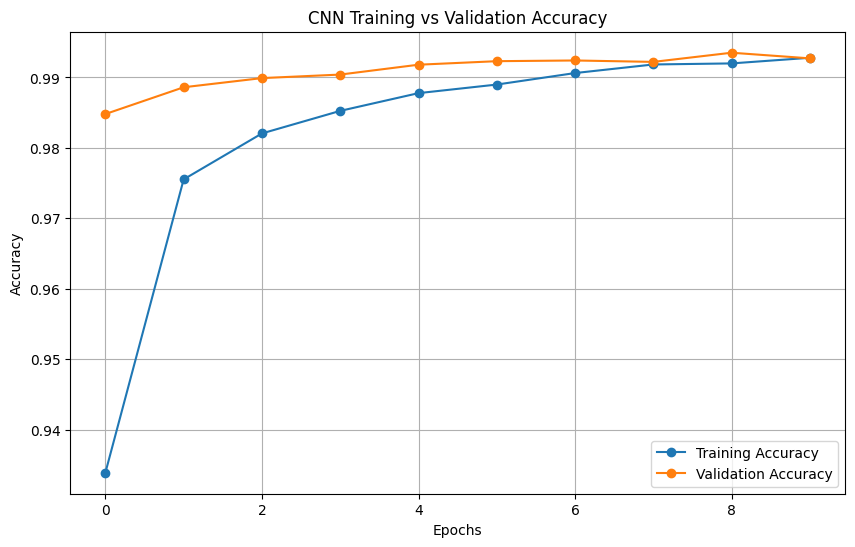

In [ ]:
plt.figure(figsize=(10, 6)) # Correct figure size format
plt.plot(history.history['accuracy'], '-o', label='Training Accuracy')
plt.plot(history.history['val_accuracy'], '-o', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('CNN Training vs Validation Accuracy')
plt.grid(True) # Add grid for better visualization
plt.show()

# **Make Predictions**

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


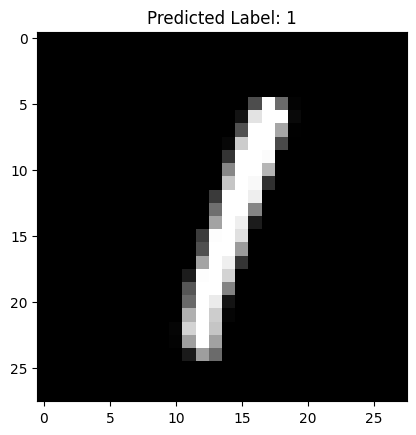

In [ ]:
# Make predictions on test data
predictions = model.predict(x_test)
# Show an example prediction
def display_prediction(index):
  plt.imshow(x_test[index].reshape(28,28), cmap='gray')
  plt.title(f'Predicted Label: {np.argmax(predictions[index])}')
  plt.show()
display_prediction(5)